# ETF Decay Capture Backtest

**Universe, borrow, and sizing now come from the sibling `etf-dashboard` repo.

- **Borrow rates:** IBKR *average* borrow (`borrow_avg_annual` from `etf-dashboard/data/dashboard_data.json`).
- **AUM filter:** only trade ETFs with AUM `> $20M` (`etf-dashboard/data/etf_metrics_daily.csv`, yfinance fallback).
- **Sizing:** weights driven by the largest expected `net_decay_annual` (from the dashboard), then capped by `% of AUM` and `% of shares_available`, plus per-pair / per-underlying concentration caps (v15 style).
- All beta buckets allowed; AUM filter is the binding universe rule.

Outputs: CAGR, annualised vol, max drawdown, a stacked-area chart of each pair’s % of total gross over time, plus a bar chart of gross concentration by underlying.

## Setup

In [77]:
import warnings; warnings.filterwarnings("ignore")
import json, io, time, os, ftplib
import numpy as np, pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

TRADING_DAYS = 252
norm_sym = lambda x: str(x).strip().upper().replace(".", "-")
print("Imports OK")


Imports OK


## Configuration

In [78]:
CFG = {
    "capital_usd":          25_000_000,
    "start_date":           "2023-01-01",
    "slippage_bps":         10,
    "ibkr_comm_per_share":  0.005,
    "ibkr_comm_min":        1.00,
    "ibkr_comm_max_pct":    0.005,
    "fallback_borrow_rate": 0.02,
    "margin_debit_spreads": [
        (100_000,      0.015),
        (1_000_000,    0.010),
        (50_000_000,   0.0075),
        (float("inf"), 0.005),
    ],
    "credit_threshold":     10_000,
    "credit_spread":        -0.005,
    "dead_band_pct":        0.02,
    "gross_dead_band_pct":  0.05,
    # --- v8 sizing knobs (v15-style caps) ---
    "aum_min_usd":            20_000_000,   # universe filter: only ETFs with AUM > $20m
    "aum_use_pct":            0.02,        # short position <= 2% of reported AUM
    "short_avail_use_pct":    0.25,        # short position <= 25% of reported shares_available
    "max_pair_weight_cap":    0.075,       # per-pair weight cap (% of gross)
    "max_underlying_weight_cap": 0.15,     # per-underlying weight cap
    "missing_shares_cap":     0.02,        # fallback cap when shares_available missing
    "decay_weight_power":     1.25,        # exponent on net_decay signal
    "min_net_decay_annual":   0.05,        # sizing: require net_decay_annual > 5% (else zero weight)
    "borrow_penalty_mult":    3.0,         # sizing: score /= (1 + mult * borrow_annual); higher = penalize borrow more
    "use_pair_pnl_filter":    True,        # if ALL_PAIR_PNL exists, exclude ETFs with negative cumulative pair P&L
    "cap_ramp_rebals":        3,           # rebalances to ramp cap-constrained names in
}

LEVERAGE_RUNS = [3]

V7_TARGET_LEV_START = 2.75
V7_TARGET_LEV_END   = 3.25

print(f"Capital: ${CFG['capital_usd']:,}  |  Start: {CFG['start_date']}")
print(f"Leverage: {LEVERAGE_RUNS}  |  target gross multiple: {V7_TARGET_LEV_START}x -> {V7_TARGET_LEV_END}x")
print(f"Universe filter: AUM > ${CFG['aum_min_usd']:,}  |  all beta buckets allowed")
print(f"Position caps: AUM={CFG['aum_use_pct']:.1%}, shares_avail={CFG['short_avail_use_pct']:.1%}, "
      f"pair={CFG['max_pair_weight_cap']:.1%}, underlying={CFG['max_underlying_weight_cap']:.1%}")
print(f"Sizing: net_decay > {CFG['min_net_decay_annual']:.0%}, borrow_penalty_mult={CFG['borrow_penalty_mult']}, "
      f"pair_pnl_filter={CFG['use_pair_pnl_filter']}")


Capital: $25,000,000  |  Start: 2023-01-01
Leverage: [3]  |  target gross multiple: 2.75x -> 3.25x
Universe filter: AUM > $20,000,000  |  all beta buckets allowed
Position caps: AUM=2.0%, shares_avail=25.0%, pair=7.5%, underlying=15.0%
Sizing: net_decay > 5%, borrow_penalty_mult=3.0, pair_pnl_filter=True


## ETF Dashboard inputs — AUM, IBKR avg borrow, shares available

Pulls the latest snapshot from the sibling `etf-dashboard` repo at `../etf-dashboard/data/`. This gives us:
- `borrow_avg_annual` — average IBKR borrow fee (used everywhere as *the* borrow rate).
- `shares_available` — most recent IBKR lendable share count.
- `net_decay_annual` (from `net_decay`) — expected P&L signal used to size positions.
- `aum` per ticker — used for the $20M universe filter and the AUM cap.

In [79]:
# ---- Load ETF-dashboard inputs (AUM, IBKR avg borrow, shares, net decay) ----
dashboard_candidates = [
    Path("../etf-dashboard/data"),
    Path("../../etf-dashboard/data"),
    Path.cwd().parent / "etf-dashboard/data",
    Path(r"C:/Users/werdn/Documents/Investing/etf-dashboard/data"),
]
DASHBOARD_DIR = next((p for p in dashboard_candidates if p.exists()), None)
if DASHBOARD_DIR is None:
    raise FileNotFoundError(
        "Could not locate etf-dashboard/data. Checked: "
        + ", ".join(str(p) for p in dashboard_candidates)
    )
print(f"[dashboard] Using {DASHBOARD_DIR}")

with open(DASHBOARD_DIR / "dashboard_data.json", "r", encoding="utf-8") as f:
    _dash = json.load(f)
_records = _dash.get("records", []) or []
print(f"[dashboard] records loaded: {len(_records)}")

_dash_rows = []
for r in _records:
    sym = str(r.get("symbol", "")).upper().strip().replace(".", "-")
    if not sym:
        continue
    _dash_rows.append({
        "ETF": sym,
        "Underlying": str(r.get("underlying", "")).upper().strip().replace(".", "-"),
        "Beta": r.get("beta"),
        "bucket": r.get("bucket"),
        "borrow_avg_annual": r.get("borrow_avg_annual"),
        "borrow_current": r.get("borrow_current"),
        "borrow_net_annual": r.get("borrow_net_annual"),
        "shares_available": r.get("shares_available"),
        "gross_decay_annual": r.get("gross_decay_annual"),
        "net_decay_annual": r.get("net_decay"),
    })
dash_df = pd.DataFrame(_dash_rows)
for c in ["Beta", "borrow_avg_annual", "borrow_current", "borrow_net_annual",
          "shares_available", "gross_decay_annual", "net_decay_annual"]:
    dash_df[c] = pd.to_numeric(dash_df[c], errors="coerce")
dash_df = dash_df.drop_duplicates(subset=["ETF"], keep="last").reset_index(drop=True)
print(
    f"[dashboard] unique tickers: {dash_df['ETF'].nunique()} | "
    f"with borrow_avg: {dash_df['borrow_avg_annual'].notna().sum()} | "
    f"with shares_avail: {dash_df['shares_available'].notna().sum()} | "
    f"with net_decay: {dash_df['net_decay_annual'].notna().sum()}"
)

# ---- AUM from etf_metrics_daily.csv (latest non-na per ticker) ----
aum_csv = DASHBOARD_DIR / "etf_metrics_daily.csv"
aum_df = pd.read_csv(aum_csv)
aum_df["date"] = pd.to_datetime(aum_df["date"], errors="coerce")
aum_df["ticker"] = aum_df["ticker"].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
aum_df["aum"] = pd.to_numeric(aum_df["aum"], errors="coerce")
aum_df["shares_outstanding"] = pd.to_numeric(aum_df.get("shares_outstanding"), errors="coerce")
_aum_sorted = aum_df.dropna(subset=["aum"]).sort_values("date")
aum_latest = _aum_sorted.groupby("ticker", as_index=False).tail(1)[[
    "ticker", "aum", "shares_outstanding"
]].rename(columns={"ticker": "ETF", "aum": "aum_usd"})
print(
    f"[dashboard] AUM coverage: {aum_latest['ETF'].nunique()} tickers | "
    f"median AUM: ${aum_latest['aum_usd'].median():,.0f} | "
    f">${CFG['aum_min_usd']:,}: {(aum_latest['aum_usd'] > CFG['aum_min_usd']).sum()}"
)

DASH_DF = dash_df.merge(aum_latest, on="ETF", how="left")

# Convenience maps for downstream cells.
BORROW_AVG_MAP = dict(
    zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["borrow_avg_annual"], errors="coerce"))
)
SHARES_AVAIL_MAP = dict(
    zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["shares_available"], errors="coerce"))
)
NET_DECAY_MAP = dict(
    zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["net_decay_annual"], errors="coerce"))
)
AUM_MAP = dict(zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["aum_usd"], errors="coerce")))
SHARES_OUT_MAP = dict(
    zip(DASH_DF["ETF"], pd.to_numeric(DASH_DF["shares_outstanding"], errors="coerce"))
)


[dashboard] Using ..\..\etf-dashboard\data
[dashboard] records loaded: 402
[dashboard] unique tickers: 402 | with borrow_avg: 400 | with shares_avail: 400 | with net_decay: 390
[dashboard] AUM coverage: 396 tickers | median AUM: $20,346,856 | >$20,000,000: 199


## Universe — hardcoded core + screener adds, filtered by AUM > $20M

Same hardcoded core pair list as v7/v8 before; we additionally add any pair that appears in `data/etf_screened_today.csv` (all buckets, any beta). **Whitelist ETFs** from `config/strategy_config.yml` (`portfolio.sleeves.whitelist_stock.universe.etfs`) are merged as pairs (underlying from screener, else core map, else dashboard) before the AUM step. The **AUM > $20M** filter is the final gate — pairs whose ETF has AUM ≤ $20M (or unknown AUM) are dropped here.

In [80]:
# Hardcoded from DC_Universe_Map_Filtered.xlsx (sheet "Universe Map").
CANDIDATES = [
    ("SMU", "SMR", 1.986),   ("SMUP", "SMR", 2.058),  ("QBTX", "QBTS", 1.993),
    ("BMNU", "BMNR", 1.944), ("BMNG", "BMNR", 1.993), ("ASTX", "ASTS", 1.990),
    ("CRWG", "CRWV", 1.997), ("CWVX", "CRWV", 1.990), ("WULX", "WULF", 1.997),
    ("NEBX", "NBIS", 1.999), ("NBIL", "NBIS", 1.998), ("NBIG", "NBIS", 2.009),
    ("SMCL", "SMCI", 1.990), ("CRCA", "CRCL", 1.978), ("CRCG", "CRCL", 1.990),
    ("LABX", "ALAB", 1.994), ("BEX", "BE", 1.977),    ("CLSX", "CLSK", 1.999),
    ("GLXU", "GLXY", 2.012), ("XXRP", "XRPZ", 2.020), ("XRPT", "XRPZ", 2.018),
    ("ETHU", "ETHA", 2.001), ("ETHT", "ETHA", 1.991), ("ETU", "ETHA", 1.990),
    ("CRDU", "CRDO", 1.988), ("FIGG", "FIG", 1.996),  ("SOLT", "SOEZ", 2.014),
    ("CONL", "COIN", 1.987), ("APPX", "APP", 1.984),  ("UUUG", "UUUU", 1.995),
    ("SOXL", "SOXX", 2.960), ("ROBN", "HOOD", 2.012), ("HOOG", "HOOD", 2.007),
    ("LITX", "LITE", 1.980), ("INTW", "INTC", 1.988), ("UPSX", "UPST", 1.989),
    ("CSEX", "CLS", 1.998),  ("MUU", "MU", 1.994),    ("MULL", "MU", 1.997),
    ("ARCX", "ACHR", 1.989), ("SATG", "SATS", 2.010), ("VRTL", "VRT", 1.982),
    ("GDXU", "GDX", 3.043),  ("NUGT", "GDX", 1.981),  ("TEMT", "TEM", 1.985),
    ("RDTL", "RDDT", 1.982), ("RBLU", "RBLX", 2.019), ("AMDL", "AMD", 1.997),
    ("AMUU", "AMD", 2.008),  ("AMDG", "AMD", 2.003),  ("TSLL", "TSLA", 1.993),
    ("TSLT", "TSLA", 1.993), ("TSLR", "TSLA", 1.999), ("TSLG", "TSLA", 1.991),
    ("BITX", "IBIT", 2.005), ("BITU", "IBIT", 1.992), ("BTCL", "IBIT", 2.007),
    ("YINN", "FXI", 2.974),  ("MVLL", "MRVL", 1.992), ("URAA", "URA", 1.933),
    ("SNOU", "SNOW", 2.024), ("BULG", "BULL", 1.985), ("PLTU", "PLTR", 1.992),
    ("PTIR", "PLTR", 1.997), ("PLTG", "PLTR", 1.996), ("BABX", "BABA", 2.006),
    ("NVDL", "NVDA", 1.988), ("NVDU", "NVDA", 1.986), ("NVDX", "NVDA", 1.997),
    ("NVDG", "NVDA", 1.969), ("LRCU", "LRCX", 2.045), ("ARMG", "ARM", 1.997),
    ("TSMU", "TSM", 1.990),  ("TSMG", "TSM", 1.979),  ("GEVX", "GEV", 1.993),
    ("KTUP", "KTOS", 2.026), ("AVL", "AVGO", 1.987),  ("AVGG", "AVGO", 1.999),
    ("AVGU", "AVGO", 1.992), ("UBRL", "UBER", 1.995), ("CRMG", "CRM", 1.984),
    ("UNHG", "UNH", 1.996),  ("MEXX", "EWW", 2.958),  ("JNUG", "GDXJ", 1.974),
    ("NFLU", "NFLX", 1.990), ("CWEB", "KWEB", 1.987), ("CEGX", "CEG", 1.979),
    ("GGLL", "GOOGL", 1.992),("GOOX", "GOOGL", 1.984),("KORU", "EWY", 2.931),
    ("TERG", "TER", 1.996),  ("DLLL", "DELL", 1.986), ("METU", "META", 1.999),
    ("FBL", "META", 1.997),  ("AMZU", "AMZN", 1.987), ("AMZZ", "AMZN", 1.992),
    ("PALU", "PANW", 2.006), ("ASMG", "ASML", 1.984), ("WDCX", "WDC", 2.055),
    ("CRWL", "CRWD", 1.997), ("ELIL", "LLY", 1.991),  ("PYPG", "PYPL", 1.995),
    ("BOEU", "BA", 1.987),   ("MSFU", "MSFT", 1.991), ("MSFL", "MSFT", 1.992),
    ("MSFX", "MSFT", 2.007), ("CHAU", "ASHR", 1.967), ("NOWL", "NOW", 1.996),
    ("ERX", "XLE", 1.988),   ("GUSH", "XOP", 2.011),  ("SHPU", "SHOP", 2.012),
    ("XOMX", "XOM", 1.969),  ("ORCU", "ORCL", 2.006), ("ADBG", "ADBE", 1.992),
    ("AAPU", "AAPL", 1.984), ("AAPB", "AAPL", 1.991), ("AAPX", "AAPL", 1.995),
    ("TARK", "ARKK", 1.978), ("LABU", "XBI", 2.988),  ("CSCL", "CSCO", 2.027),
    ("LMTL", "LMT", 1.984),  ("COTG", "COST", 1.987),
]
_pre_screen_candidates = list(CANDIDATES)
_base_keys = {(e, u) for e, u, _ in CANDIDATES}

BUCKET3_CANDIDATES = [
    ("APLZ", "APLD"),
    ("CLSZ", "CLSK"),
    ("IREZ", "IREN"),
    ("BEZ", "BE"),
    ("NBIZ", "NBIS"),
    ("SMZ", "SMR"),
    ("MSTZ", "MSTR"),
    ("TSLQ", "TSLA"),
    ("NVDQ", "NVDA"),
    ("SOXS", "SOXX"),
]
BUCKET3_ETFS = {e for e, _ in BUCKET3_CANDIDATES}
BUCKET3_UNDERLYINGS = {u for _, u in BUCKET3_CANDIDATES}


# Augment from latest screener CSV (all buckets; no beta filter here — AUM is the gate).
_screen_candidates = [
    Path("../data/etf_screened_today.csv"),
    Path("data/etf_screened_today.csv"),
    DASHBOARD_DIR / "etf_screened_today.csv",
]
_screen_path = next((p for p in _screen_candidates if p.exists()), None)
added_from_screener = 0
if _screen_path is not None:
    _sc = pd.read_csv(_screen_path)
    _sc.columns = [str(c).strip() for c in _sc.columns]
    if {"ETF", "Underlying", "Beta"}.issubset(_sc.columns):
        for r in _sc.itertuples(index=False):
            e = str(r.ETF).upper().strip().replace(".", "-")
            u = str(r.Underlying).upper().strip().replace(".", "-")
            b = float(r.Beta) if pd.notna(r.Beta) else np.nan
            if not e or not u or not np.isfinite(b):
                continue
            key = (e, u)
            if key in _base_keys:
                continue
            CANDIDATES.append((e, u, round(abs(b), 3)))
            _base_keys.add(key)
            added_from_screener += 1
print(f"Core + screener candidates: {len(CANDIDATES)} ({added_from_screener} from screener)")

# ---- Whitelist from config/strategy_config.yml (portfolio.sleeves.whitelist_stock.universe.etfs) ----
# Resolved to (ETF, underlying) via screener CSV, else core list, else dashboard. Same AUM > $20M gate below.
WHITELIST_ETFS = set()
_cfg_candidates = [Path("config/strategy_config.yml"), Path("../config/strategy_config.yml")]
_cfg_path = next((p for p in _cfg_candidates if p.exists()), None)
if _cfg_path is not None:
    try:
        import yaml

        with open(_cfg_path, "r", encoding="utf-8") as f:
            _cfg_obj = yaml.safe_load(f) or {}
        _wl = (
            (((_cfg_obj.get("portfolio", {}) or {}).get("sleeves", {}) or {}).get("whitelist_stock", {}) or {})
            .get("universe", {})
            .get("etfs", [])
        )
        WHITELIST_ETFS = {
            str(x).upper().strip().replace(".", "-")
            for x in (_wl or [])
            if str(x).strip()
        }
    except Exception:
        WHITELIST_ETFS = set()

_base_etf_to_und = {}
for _e0, _u0, _b0 in _pre_screen_candidates:
    _base_etf_to_und.setdefault(
        str(_e0).upper().strip().replace(".", "-"), str(_u0).upper().strip().replace(".", "-")
    )

_screen_etf_to_und = {}
if _screen_path is not None and {"ETF", "Underlying"}.issubset(_sc.columns):
    _tmp_sc = _sc[["ETF", "Underlying"]].dropna().copy()
    _tmp_sc["ETF"] = _tmp_sc["ETF"].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
    _tmp_sc["Underlying"] = (
        _tmp_sc["Underlying"].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
    )
    _tmp_sc = _tmp_sc[(_tmp_sc["ETF"] != "") & (_tmp_sc["Underlying"] != "")]
    _tmp_sc = _tmp_sc.drop_duplicates(subset=["ETF"], keep="first")
    _screen_etf_to_und = dict(zip(_tmp_sc["ETF"], _tmp_sc["Underlying"]))

_seen_pairs = {(e, u) for e, u, _ in CANDIDATES}
_added_wl = 0
_skipped_wl = []
for _e in sorted(WHITELIST_ETFS):
    _u = _screen_etf_to_und.get(_e, _base_etf_to_und.get(_e, ""))
    if not _u and "DASH_DF" in dir():
        _row = DASH_DF.loc[DASH_DF["ETF"] == _e]
        if not _row.empty:
            _u = str(_row["Underlying"].iloc[0]).upper().strip().replace(".", "-")
    if not _u:
        _skipped_wl.append(_e)
        continue
    _k = (_e, _u)
    if _k in _seen_pairs:
        continue
    CANDIDATES.append((_e, _u, 1.0))
    _seen_pairs.add(_k)
    _base_keys.add(_k)
    _added_wl += 1
if _added_wl > 0:
    print(f"[v8] Added whitelist pairs from strategy_config.yml: {_added_wl} (subject to AUM filter next)")
if WHITELIST_ETFS and _skipped_wl:
    print(f"[v8] Whitelist ETFs skipped (no underlying resolved): {', '.join(_skipped_wl)}")

# ---- AUM > $20M filter ----
aum_min = float(CFG["aum_min_usd"])
filtered, dropped_aum, dropped_missing = [], 0, 0
for e, u, b in CANDIDATES:
    aum = AUM_MAP.get(e)
    if aum is None or not np.isfinite(aum):
        dropped_missing += 1
        continue
    if aum <= aum_min:
        dropped_aum += 1
        continue
    filtered.append((e, u, b))
CANDIDATES = filtered
print(
    f"After AUM>${aum_min:,.0f} filter: {len(CANDIDATES)} pairs "
    f"(dropped: {dropped_aum} below threshold, {dropped_missing} missing AUM)"
)


Core + screener candidates: 398 (276 from screener)
After AUM>$20,000,000 filter: 197 pairs (dropped: 195 below threshold, 6 missing AUM)


## Data — IBKR avg borrow + total-return prices + Fed Funds

In [81]:
# ---- Borrow rates from etf-dashboard (IBKR avg) ----
all_etf_syms = [e for e, _, _ in CANDIDATES]

BORROW_MAP = {}
src_avg = src_net = src_cur = src_flat = 0
for e in all_etf_syms:
    v_avg = BORROW_AVG_MAP.get(e)
    if v_avg is not None and np.isfinite(v_avg) and v_avg > 0:
        BORROW_MAP[e] = float(v_avg)
        src_avg += 1
        continue
    row = DASH_DF.loc[DASH_DF["ETF"] == e]
    v_net = float(row["borrow_net_annual"].iloc[0]) if not row.empty else np.nan
    v_cur = float(row["borrow_current"].iloc[0]) if not row.empty else np.nan
    if np.isfinite(v_net) and v_net > 0:
        BORROW_MAP[e] = v_net; src_net += 1
    elif np.isfinite(v_cur) and v_cur > 0:
        BORROW_MAP[e] = v_cur; src_cur += 1
    else:
        BORROW_MAP[e] = float(CFG["fallback_borrow_rate"]); src_flat += 1

print(
    f"[BORROW] IBKR borrow_avg_annual: {src_avg}/{len(all_etf_syms)} | "
    f"net_annual: {src_net} | current: {src_cur} | flat fallback: {src_flat}"
)
print(
    f"[BORROW] mean rate (applied): "
    f"{np.mean([v for v in BORROW_MAP.values()]):.2%}"
)


[BORROW] IBKR borrow_avg_annual: 197/197 | net_annual: 0 | current: 0 | flat fallback: 0
[BORROW] mean rate (applied): 15.82%


In [82]:
# ---- Total-return prices (yfinance adjusted close) ----
import yfinance as yf

MANUAL_SPLIT_OVERRIDES = {
    "SMUP": {"2026-01-26": 10.0},
    "EOSU": {"2026-04-08": 25.0},
}

def download_total_return(ticker, period="max"):
    try:
        tk = yf.Ticker(ticker)
        df = tk.history(period=period, auto_adjust=False, actions=True)
        if df.empty or "Close" not in df.columns:
            return None
        df = df.sort_index()
        tkr = str(ticker).upper()
        manual_splits = globals().get("MANUAL_SPLIT_OVERRIDES", {})
        force_raw = tkr in manual_splits
        if (not force_raw) and ("Adj Close" in df.columns) and df["Adj Close"].notna().sum() > 20:
            tr = df["Adj Close"].astype(float)
            tr.index = tr.index.tz_localize(None)
            return tr.replace([np.inf, -np.inf], np.nan).dropna()
        close = df["Close"].astype(float)
        divs = df["Dividends"].fillna(0).astype(float) if "Dividends" in df.columns else pd.Series(0.0, index=close.index)
        splits = df["Stock Splits"].replace(0, 1).fillna(1).astype(float) if "Stock Splits" in df.columns else pd.Series(1.0, index=close.index)
        if tkr in manual_splits:
            for ds, factor in manual_splits[tkr].items():
                ts = pd.Timestamp(ds)
                apply_ts = None
                if ts in splits.index:
                    apply_ts = ts
                else:
                    nxt = splits.index[splits.index >= ts]
                    if len(nxt) > 0 and (nxt[0] - ts).days <= 3:
                        apply_ts = nxt[0]
                if apply_ts is None:
                    continue
                f = float(factor)
                close.loc[close.index < apply_ts] = close.loc[close.index < apply_ts] * f
                divs.loc[divs.index < apply_ts] = divs.loc[divs.index < apply_ts] * f
                splits.loc[apply_ts] = 1.0
        gross = ((close * splits) + divs) / close.shift(1)
        gross = gross.replace([np.inf, -np.inf], np.nan).fillna(1.0)
        tr = close.iloc[0] * gross.cumprod()
        tr.index = tr.index.tz_localize(None)
        return tr.replace([np.inf, -np.inf], np.nan).dropna()
    except Exception:
        return None

ALL_TICKERS = sorted(set(e for e, _, _ in CANDIDATES) | set(u for _, u, _ in CANDIDATES) | {"SPY"})
t0 = time.time()
print(f"Downloading {len(ALL_TICKERS)} tickers...")
PRICES = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(download_total_return, t): t for t in ALL_TICKERS}
    done = 0
    for f in as_completed(futs):
        done += 1
        t = futs[f]
        s = f.result()
        if s is not None and len(s) > 20:
            PRICES[t] = s
        if done % 40 == 0:
            print(f"  {done}/{len(ALL_TICKERS)} [{time.time()-t0:.0f}s]")
print(f"Got {len(PRICES)}/{len(ALL_TICKERS)} [{time.time()-t0:.1f}s]")

# ---- Fed Funds ----
try:
    ff_df = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF")
    ff_df.columns = [str(c).strip() for c in ff_df.columns]
    date_col = "DATE" if "DATE" in ff_df.columns else "observation_date"
    ff_df["date"] = pd.to_datetime(ff_df[date_col], errors="coerce")
    ff_df["rate"] = pd.to_numeric(ff_df["DFF"], errors="coerce")
    ff_df = ff_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
    FED_FUNDS_DAILY = (ff_df["rate"] / 100).astype(float)
    print(f"Fed Funds: {len(FED_FUNDS_DAILY)} daily obs")
except Exception as e:
    print(f"FRED failed ({e}); using constant 4% fallback")
    FED_FUNDS_DAILY = pd.Series([0.04], index=[pd.Timestamp("2020-01-01")])


  40/295 [5s]
  80/295 [6s]
  120/295 [7s]
  160/295 [8s]
  200/295 [9s]
  240/295 [10s]
  280/295 [12s]
Got 294/295 [12.5s]
Fed Funds: 26223 daily obs


In [83]:
# ---- Inception dates + full UNIVERSE (pairs with overlapping price data) ----
start_ts = pd.Timestamp(CFG["start_date"])

INCEPTION = {}
for etf, und, bv in CANDIDATES:
    s_e = PRICES.get(etf); s_u = PRICES.get(und)
    if s_e is not None and s_u is not None:
        INCEPTION[(etf, und)] = max(s_e.index[0], s_u.index[0])

UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])
RAMP_WEEKS = 4
n_at_start = sum(1 for e, u, b in UNIVERSE if INCEPTION[(e, u)] <= start_ts)
print(
    f"Full UNIVERSE: {len(UNIVERSE)} pairs | tradeable at start ({CFG['start_date']}): {n_at_start} | "
    f"RAMP_WEEKS={RAMP_WEEKS}"
)


Full UNIVERSE: 196 pairs | tradeable at start (2023-01-01): 60 | RAMP_WEEKS=4


## Cost functions

In [84]:
def trade_cost(tusd, px, cfg):
    if abs(tusd) < 1 or px <= 0:
        return 0.0
    sh = abs(tusd) / px
    return max(cfg["ibkr_comm_min"], min(sh * cfg["ibkr_comm_per_share"], abs(tusd) * cfg["ibkr_comm_max_pct"])) + abs(tusd) * cfg["slippage_bps"] / 10000

def margin_debit_interest(debit, benchmark_rate, spreads):
    if debit <= 0:
        return 0.0
    remaining, interest, prev = debit, 0.0, 0.0
    for threshold, spread in spreads:
        rate = max(0.0, benchmark_rate + spread)
        amt = min(remaining, threshold - prev)
        if amt > 0:
            interest += amt * rate / TRADING_DAYS
            remaining -= amt
        prev = threshold
        if remaining <= 0:
            break
    return interest

def short_credit_interest(short_notional, benchmark_rate, credit_spread):
    if short_notional <= 0:
        return 0.0
    return short_notional * max(0.0, benchmark_rate + credit_spread) / TRADING_DAYS

def _get_fed_funds(dt):
    val = FED_FUNDS_DAILY.asof(dt)
    return 0.04 if pd.isna(val) else float(val)

def perf(nav):
    r = nav.pct_change().dropna()
    ny = len(nav) / TRADING_DAYS
    cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1 / ny) - 1 if ny > 0 else np.nan
    vol = r.std() * (TRADING_DAYS ** 0.5)
    sr = cagr / vol if vol > 0 else np.nan
    dd = (nav - nav.cummax()) / nav.cummax()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sr, "Max DD": dd.min(),
            "Final NAV": nav.iloc[-1], "P&L": nav.iloc[-1] - nav.iloc[0]}
print("Cost functions OK")


Cost functions OK


## Sizing — net-decay signal with AUM + shares caps

Raw scores use `net_decay_annual ** decay_weight_power` divided by `(1 + borrow_penalty_mult * borrow_annual)` so high borrow reduces size. Names with `net_decay_annual` **≤ `min_net_decay_annual`** (default 5%) get zero raw score. If `ALL_PAIR_PNL` exists from a **prior** backtest run and `use_pair_pnl_filter` is true, names with **negative** cumulative pair P&amp;L (long + short legs) are excluded. *Run sizing twice (after backtest) to apply the P&amp;L gate.*

Dashboard `net_decay_annual` already reflects borrow in the decay estimate; the extra borrow divisor is an additional sizing penalty.

Each weight is then capped so that the implied *short* leg is no more than:

- `aum_use_pct` of the ETF’s AUM, **and**
- `short_avail_use_pct` of IBKR `shares_available`, **and**
- `max_pair_weight_cap` of portfolio gross (per pair), **and**
- `max_underlying_weight_cap` of portfolio gross (aggregate per underlying).

Infeasible weight is reallocated proportionally to pairs with remaining headroom (v15-style capped-simplex projection).

In [85]:
# ---- Build sizing weights: net-decay signal + AUM/shares caps ----
etfs = [e for e, _, _ in UNIVERSE]
beta_map = {e: abs(b) for e, _, b in UNIVERSE}
und_map  = {e: u for e, u, _ in UNIVERSE}

assumed_nav_usd          = float(CFG["capital_usd"])
assumed_target_lev       = float(V7_TARGET_LEV_END)
assumed_target_gross_usd = assumed_nav_usd * assumed_target_lev

aum_use_pct          = float(CFG["aum_use_pct"])
short_avail_use_pct  = float(CFG["short_avail_use_pct"])
max_pair_cap         = float(CFG["max_pair_weight_cap"])
max_und_cap          = float(CFG["max_underlying_weight_cap"])
missing_shares_cap   = float(CFG["missing_shares_cap"])
decay_pw             = float(CFG["decay_weight_power"])

ref_date_for_px = max((s.index[-1] for s in PRICES.values()), default=pd.Timestamp.today())

# ---- Raw weights: net_decay gates + borrow penalty on sizing score ----
min_nd = float(CFG.get("min_net_decay_annual", 0.05))
borrow_pm = float(CFG.get("borrow_penalty_mult", 3.0))
_use_pnl_f = bool(CFG.get("use_pair_pnl_filter", True))

pair_pnl_total = {}
if _use_pnl_f and "ALL_PAIR_PNL" in dir() and ALL_PAIR_PNL:
    _lev = max(ALL_PAIR_PNL.keys())
    _pp = ALL_PAIR_PNL[_lev]
    if isinstance(_pp, dict):
        for _e, _r in _pp.items():
            if isinstance(_r, dict):
                pair_pnl_total[str(_e).upper().strip().replace(".", "-")] = float(_r.get("long", 0.0)) + float(
                    _r.get("short", 0.0)
                )

decay_values = {}
n_excl_nd = n_excl_pnl = 0
for e in etfs:
    nd = NET_DECAY_MAP.get(e, np.nan)
    ndv = max(0.0, float(nd) if pd.notna(nd) else 0.0)
    if ndv <= min_nd + 1e-12:
        decay_values[e] = 0.0
        n_excl_nd += 1
        continue
    if pair_pnl_total:
        eu = str(e).upper().strip().replace(".", "-")
        if eu in pair_pnl_total and pair_pnl_total[eu] < 0:
            decay_values[e] = 0.0
            n_excl_pnl += 1
            continue
    decay_values[e] = ndv

decay_arr = pd.Series(
    {
        e: (
            (decay_values[e] ** decay_pw)
            / (1.0 + borrow_pm * float(BORROW_MAP.get(e, CFG["fallback_borrow_rate"])))
            if decay_values[e] > 0
            else 0.0
        )
        for e in etfs
    },
    dtype=float,
)
print(
    f"[weights] gates: min_net_decay>{min_nd:.0%} excluded {n_excl_nd}/{len(etfs)}, "
    f"borrow_penalty_mult={borrow_pm}"
)
if pair_pnl_total:
    print(f"[weights] pair PnL filter: excluded {n_excl_pnl} negative cumulative P&L (ALL_PAIR_PNL)")
else:
    print("[weights] pair PnL filter: skipped (no ALL_PAIR_PNL — run backtest then re-run sizing to apply)")

if decay_arr.sum() <= 0:
    print("[weights] all scores zero -> equal weight fallback")
    decay_arr[:] = 1.0
raw_weight = decay_arr / decay_arr.sum()

# ---- Per-pair capacity cap from AUM + shares_available ----
cap_frac = {}
for e in etfs:
    babs = max(1e-9, beta_map.get(e, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)        # short-leg $ / pair-gross $
    ref_short_budget = assumed_target_gross_usd * short_frac
    px_ser = PRICES.get(e)
    px_e = float(px_ser.asof(ref_date_for_px)) if px_ser is not None else np.nan

    sh_av = SHARES_AVAIL_MAP.get(e, np.nan)
    aum   = AUM_MAP.get(e, np.nan)

    shares_cap_w = np.nan
    if pd.notna(sh_av) and sh_av > 0 and pd.notna(px_e) and px_e > 0:
        shares_cap_usd = float(sh_av) * short_avail_use_pct * px_e
        shares_cap_w = shares_cap_usd / max(1.0, ref_short_budget)

    aum_cap_w = np.nan
    if pd.notna(aum) and aum > 0:
        aum_cap_usd = float(aum) * aum_use_pct
        aum_cap_w = aum_cap_usd / max(1.0, ref_short_budget)

    candidates = [c for c in (shares_cap_w, aum_cap_w) if pd.notna(c)]
    pair_cap = min(candidates) if candidates else missing_shares_cap
    cap_frac[e] = float(min(max_pair_cap, max(0.0, pair_cap)))

cap_s = pd.Series(cap_frac, dtype=float)

def project_to_capped_simplex(desired, caps, tol=1e-12):
    d = desired.astype(float).copy()
    c = caps.astype(float).copy().clip(lower=0.0)
    if d.sum() <= 0:
        d[:] = 1.0
    d = d / d.sum()
    if c.sum() < 1.0:
        c = np.maximum(c, d)
    w = pd.Series(0.0, index=d.index)
    free = list(d.index)
    rem = 1.0
    while free and rem > tol:
        base = d.loc[free]
        trial = (rem * base / base.sum()) if base.sum() > 0 else pd.Series(rem / len(free), index=free)
        hit = trial > (c.loc[free] + tol)
        if not hit.any():
            w.loc[free] = trial
            rem = 0.0
            break
        hit_idx = list(trial.index[hit])
        w.loc[hit_idx] = c.loc[hit_idx]
        rem = 1.0 - float(w.sum())
        free = [k for k in free if k not in hit_idx]
    if rem > tol and free:
        room = (c.loc[free] - w.loc[free]).clip(lower=0.0)
        if room.sum() > tol:
            w.loc[free] += rem * room / room.sum()
    w = w.clip(lower=0.0)
    if w.sum() > 0:
        w = w / w.sum()
    return np.minimum(w, c) / max(np.minimum(w, c).sum(), 1e-12)

pair_weight = project_to_capped_simplex(raw_weight, cap_s)

def project_pair_and_underlying(desired, pair_caps, und_series, und_cap, tol=1e-12, max_iter=200):
    w = desired.astype(float).copy().clip(lower=0.0)
    pc = pair_caps.astype(float).copy().clip(lower=0.0)
    uset = und_series.reindex(w.index).astype(str)
    if w.sum() <= 0:
        w[:] = 1.0
    w = w / w.sum()
    for _ in range(max_iter):
        prev = w.copy()
        w = np.minimum(w, pc)
        und_tot = w.groupby(uset).sum()
        over = und_tot[und_tot > und_cap + tol]
        for u, tot in over.items():
            idx = uset[uset == u].index
            if tot > 0:
                w.loc[idx] *= float(und_cap / tot)
        rem = 1.0 - float(w.sum())
        if rem > tol:
            und_tot = w.groupby(uset).sum()
            und_head = (und_cap - und_tot).clip(lower=0.0)
            name_und_head = uset.map(und_head).astype(float)
            pair_head = (pc - w).clip(lower=0.0)
            head = np.minimum(pair_head, name_und_head)
            hs = float(head.sum())
            if hs > tol:
                w += rem * (head / hs)
        if w.sum() > 0:
            w = w / w.sum()
        if float(np.max(np.abs((w - prev).values))) < 1e-10:
            break
    return w

und_series = pd.Series({e: und_map[e] for e in etfs}, dtype="object")
final_weight = project_pair_and_underlying(pair_weight, cap_s, und_series, max_und_cap)

PAIR_WEIGHTS = {e: float(final_weight[e]) for e in etfs if final_weight[e] > 0}

# ---- Weights table (for inspection + concentration chart) ----
w_rows = []
for e in etfs:
    px_ser = PRICES.get(e)
    px_e = float(px_ser.asof(ref_date_for_px)) if px_ser is not None else np.nan
    babs = max(1e-9, beta_map.get(e, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)
    aum = AUM_MAP.get(e, np.nan)
    sh_av = SHARES_AVAIL_MAP.get(e, np.nan)
    w_final = float(final_weight.get(e, 0.0))
    pair_target = w_final * assumed_target_gross_usd
    short_target = pair_target * short_frac
    w_rows.append({
        "etf": e,
        "und": und_map[e],
        "beta_abs": beta_map[e],
        "net_decay_annual": float(NET_DECAY_MAP.get(e, np.nan)),
        "borrow_avg_annual": float(BORROW_MAP.get(e, np.nan)),
        "aum_usd": float(aum) if pd.notna(aum) else np.nan,
        "aum_m": float(aum) / 1e6 if pd.notna(aum) else np.nan,
        "shares_available": float(sh_av) if pd.notna(sh_av) else np.nan,
        "etf_price": px_e,
        "weight_raw": float(raw_weight.get(e, 0.0)),
        "weight_cap": float(cap_s.get(e, 0.0)),
        "weight": w_final,
        "pair_target_gross_usd": pair_target,
        "short_target_usd": short_target,
        "short_vs_aum_pct": (short_target / float(aum)) if (pd.notna(aum) and aum > 0) else np.nan,
        "short_vs_shares_pct": (short_target / (float(sh_av) * px_e)) if (pd.notna(sh_av) and sh_av > 0 and pd.notna(px_e) and px_e > 0) else np.nan,
    })
w_df = pd.DataFrame(w_rows).sort_values("weight", ascending=False).reset_index(drop=True)

out_dir = Path("data/backtest")
out_dir.mkdir(parents=True, exist_ok=True)
w_df.to_csv(out_dir / "v8_pnl_decay_shares_weights.csv", index=False)

_top5 = w_df["weight"].nlargest(5).sum()
_top10 = w_df["weight"].nlargest(10).sum()
print(f"[weights] pairs sized: {(w_df['weight']>0).sum()}/{len(w_df)} | sum={w_df['weight'].sum():.3f}")
print(f"[weights] Top-5 concentration: {_top5:.1%} | Top-10: {_top10:.1%}")
_und_tot = w_df.groupby("und")["weight"].sum()
print(f"[weights] Max underlying concentration: {_und_tot.max():.1%} (cap {max_und_cap:.1%})")
print(w_df.head(15).to_string(index=False,
    formatters={
        "beta_abs": "{:.2f}".format,
        "net_decay_annual": "{:.2%}".format,
        "borrow_avg_annual": "{:.2%}".format,
        "aum_m": "{:,.0f}".format,
        "shares_available": "{:,.0f}".format,
        "etf_price": "{:,.2f}".format,
        "weight_raw": "{:.2%}".format,
        "weight_cap": "{:.2%}".format,
        "weight": "{:.2%}".format,
        "pair_target_gross_usd": "{:,.0f}".format,
        "short_target_usd": "{:,.0f}".format,
        "short_vs_aum_pct": "{:.2%}".format,
        "short_vs_shares_pct": "{:.2%}".format,
    }))


[weights] gates: min_net_decay>5% excluded 63/196, borrow_penalty_mult=3.0
[weights] pair PnL filter: excluded 4 negative cumulative P&L (ALL_PAIR_PNL)
[weights] pairs sized: 129/196 | sum=1.000
[weights] Top-5 concentration: 14.7% | Top-10: 26.0%
[weights] Max underlying concentration: 6.3% (cap 15.0%)
 etf  und beta_abs net_decay_annual borrow_avg_annual      aum_usd  aum_m shares_available etf_price weight_raw weight_cap weight pair_target_gross_usd short_target_usd short_vs_aum_pct short_vs_shares_pct
LITX LITE     1.98          133.26%            12.35% 5.962856e+08    596        1,200,000     45.36      2.60%      7.50%  3.90%             3,171,399        1,064,228            0.18%               1.96%
LABX ALAB     1.99           95.82%             4.55% 5.369564e+07     54          150,000     35.82      2.07%      3.96%  3.12%             2,532,257          845,777            1.58%              15.74%
OKLL OKLO     2.00          125.45%            29.02% 9.312984e+07     93    

## Backtest Engine

**Same code path as v15:** weekly `W-FRI` rebalance, dynamic `V7_TARGET_LEV_START`→`END` target gross, `gross_dead_band_pct` full resize vs dead-band incumbent hedge + post-start adds, `px_trade` execution timing, bucket-3 leg construction when `BUCKET3_ETFS` is set, pair-led borrow (ETF + shorted underlying), and book-level margin debit (`l_notional - nav`). Uses the `PAIR_WEIGHTS` built above (default missing ETF weight `1/n_pairs`).

In [86]:
spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)
B3_ETFS = frozenset(str(x).upper().strip().replace(".", "-") for x in (globals().get("BUCKET3_ETFS", set()) or set()))
B3_KEYS = frozenset((etf, und) for etf, und, _ in UNIVERSE if str(etf).upper().strip().replace(".", "-") in B3_ETFS)
B3_INC_KEYS = frozenset(k for k in B3_KEYS if INCEPTION[k] <= start_ts)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)}")
print(f"Bucket3 configured: {len(B3_ETFS)} ETFs | in-universe: {len(B3_KEYS)} | active at start: {len(B3_INC_KEYS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir():
    PAIR_WEIGHTS = {e: 1.0 / n_pairs for e, _, _ in UNIVERSE}
    print(f"Using equal weights: {1.0/n_pairs:.4%} per pair")
else:
    print(f"Using custom PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} pairs, top weight: {max(PAIR_WEIGHTS.values()):.2%})")

# Reconciliation controls for matching external sheets exactly.
# Provide overrides in a prior cell, e.g.:
# EXACT_SHARE_OVERRIDES = {
#   ("NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
#   ("2026-01-02", "NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
# }
if "EXACT_SHARE_OVERRIDES" not in dir():
    EXACT_SHARE_OVERRIDES = {}

# Optional rounding mode for share conversion: "round" (default), "floor", or "ceil".
if "SHARE_ROUNDING_MODE" not in dir():
    SHARE_ROUNDING_MODE = "round"


def _shares_from_usd(usd: float, px: float, side: str) -> int:
    if px <= 0 or usd <= 0:
        return 0
    raw = usd / px
    mode = str(SHARE_ROUNDING_MODE).lower()
    if mode == "floor":
        sh = int(np.floor(raw))
    elif mode == "ceil":
        sh = int(np.ceil(raw))
    else:
        sh = int(round(raw))
    return sh if side == "long" else -sh


def _apply_exact_share_override(today, etf: str, und: str, lsh: int, ssh: int) -> tuple[int, int]:
    day_key = str(pd.Timestamp(today).date()) if today is not None else None
    ov = None
    if day_key is not None:
        ov = EXACT_SHARE_OVERRIDES.get((day_key, etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get((etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get(etf)
    if isinstance(ov, dict):
        lsh = int(ov.get("long_sh", lsh))
        ssh = int(ov.get("short_sh", ssh))
    return lsh, ssh

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_BORROW = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}
ALL_PAIR_DAILY = {}

for gross_lev in LEVERAGE_RUNS:
    print(f"\n{'='*60}")
    print(
        f"  v8 RUN (store key {gross_lev}x) | dynamic tgt gross {V7_TARGET_LEV_START}x–{V7_TARGET_LEV_END}x"
    )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    pair_borrow = {}
    daily_rows = []
    pair_daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    prev_px = {}
    # Excel-style tradeflow state by pair leg:
    # level = cumulative trade cashflow + current marked value
    pair_long_trade_cum = {}
    pair_short_trade_cum = {}
    pair_prev_long_level = {}
    pair_prev_short_level = {}
    cum_long_pnl = cum_short_pnl = 0.0
    pair_net_rows = []
    pair_gross_rows = []

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        rows = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))
            wb = PAIR_WEIGHTS.get(etf, 1.0 / n_pairs)
            rows.append((etf, und, bv, wb * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return abs(float(pos.get("long_sh", 0.0))) * px_map.get(
            uk, 0
        ) + abs(float(pos.get("short_sh", 0.0))) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_ETFS:
            return float(V7_TARGET_LEV_START)
        on = sum(1 for ek in POST_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_ETFS))
        return V7_TARGET_LEV_START + (V7_TARGET_LEV_END - V7_TARGET_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict, today=None) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            babs = max(abs(bv), 1e-9)
            hr = 1.0 / babs
            is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS
            und_leg_usd = alloc / (1.0 + hr)
            etf_leg_usd = alloc - und_leg_usd
            if is_bucket3:
                lsh = _shares_from_usd(und_leg_usd, p_u, side="short")
                ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
            else:
                lsh = _shares_from_usd(und_leg_usd, p_u, side="long")
                ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
            lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
            pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            if etf not in pair_borrow:
                pair_borrow[etf] = 0.0
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict, today=None
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        babs = max(abs(bv), 1e-9)
        hr = 1.0 / babs
        und_leg_usd = alloc_usd / (1.0 + hr)
        etf_leg_usd = alloc_usd - und_leg_usd
        is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS
        if is_bucket3:
            lsh = _shares_from_usd(und_leg_usd, p_u, side="short")
            ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
        else:
            lsh = _shares_from_usd(und_leg_usd, p_u, side="long")
            ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
        lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        if etf not in pair_borrow:
            pair_borrow[etf] = 0.0
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        # Execution timing (for Excel tie-out use same-close execution).
        # - same_close: fills at today's close (default)
        # - prior_close: fills at previous close when available
        exec_timing = str(CFG.get("rebalance_execution_timing", "same_close")).strip().lower()
        if exec_timing in {"same_close", "close", "today_close"}:
            px_trade = dict(px)
        elif exec_timing in {"prior_close", "previous_close", "t_minus_1_close"}:
            px_trade = dict(prev_px) if (di > 0 and prev_px) else dict(px)
        else:
            raise ValueError(
                f"Unsupported rebalance_execution_timing={exec_timing!r}; "
                "use same_close or prior_close"
            )

        pair_day = {}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0))
            ssh = float(pos.get("short_sh", 0))
            und_long_val = max(lsh, 0.0) * px.get(uk, 0)
            und_short_val = max(-lsh, 0.0) * px.get(uk, 0)
            etf_short_val = max(-ssh, 0.0) * px.get(ek, 0)
            long_val = und_long_val
            short_val = und_short_val + etf_short_val
            pair_day[ek] = {
                "date": today,
                "etf": ek,
                "under": uk,
                "long_sh": lsh,
                "short_sh": ssh,
                "long_notional_usd": long_val,
                "short_notional_usd": short_val,
                "gross_notional_usd": long_val + short_val,
                "net_notional_usd": lsh * px.get(uk, 0) + ssh * px.get(ek, 0),
                "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                "daily_long_pnl_usd": 0.0,
                "daily_short_pnl_usd": 0.0,
                "daily_borrow_cost_usd": 0.0,
                "daily_underlying_borrow_cost_usd": 0.0,
                "daily_margin_debit_cost_usd": 0.0,
                "daily_short_credit_income_usd": 0.0,
                "daily_net_financing_cost_usd": 0.0,
                "daily_txn_cost_usd": 0.0,
                "daily_turnover_usd": 0.0,
            }

        daily_long_pnl = daily_short_pnl = 0.0
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0.0))
            ssh = float(pos.get("short_sh", 0.0))

            # Excel-style level method by leg:
            # level = cumulative trade cashflow + marked current value.
            long_level = float(pair_long_trade_cum.get(ek, 0.0) + lsh * px.get(uk, 0))
            short_level = float(pair_short_trade_cum.get(ek, 0.0) + ssh * px.get(ek, 0))

            prev_long_level = pair_prev_long_level.get(ek)
            prev_short_level = pair_prev_short_level.get(ek)

            if di == 0 or prev_long_level is None or prev_short_level is None:
                l_pnl = 0.0
                s_pnl = 0.0
            else:
                l_pnl = long_level - float(prev_long_level)
                s_pnl = short_level - float(prev_short_level)

            # Keep legacy MTM move for audit/debug comparison.
            if di > 0 and prev_px:
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl_mtm = lsh * dp_u if lsh > 0 else 0.0
                s_pnl_mtm = ssh * dp_e if ssh < 0 else 0.0
            else:
                l_pnl_mtm = 0.0
                s_pnl_mtm = 0.0

            pair_prev_long_level[ek] = long_level
            pair_prev_short_level[ek] = short_level

            daily_long_pnl += l_pnl
            daily_short_pnl += s_pnl
            pair_pnl[ek]["long"] += l_pnl
            pair_pnl[ek]["short"] += s_pnl

            if ek in pair_day:
                pair_day[ek]["daily_long_pnl_usd"] = float(l_pnl)
                pair_day[ek]["daily_short_pnl_usd"] = float(s_pnl)
                pair_day[ek]["daily_long_pnl_usd_mtm"] = float(l_pnl_mtm)
                pair_day[ek]["daily_short_pnl_usd_mtm"] = float(s_pnl_mtm)
                pair_day[ek]["excel_long_pnl_level_usd"] = float(long_level)
                pair_day[ek]["excel_short_pnl_level_usd"] = float(short_level)

        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for ek, pos in pair_pos.items():
            sh_short_etf = float(pos.get("short_sh", 0))
            sh_short_und = float(pos.get("long_sh", 0))
            b_etf = 0.0
            b_und = 0.0
            if sh_short_etf < 0:
                b_etf = (
                    abs(sh_short_etf)
                    * px.get(ek, 0)
                    * BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
            if sh_short_und < 0:
                und_sym = pos.get("und")
                b_und = (
                    abs(sh_short_und)
                    * px.get(und_sym, 0)
                    * BORROW_MAP.get(und_sym, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
            b = float(b_etf + b_und)
            if b > 0:
                borrow_d += b
                pair_borrow[ek] = pair_borrow.get(ek, 0.0) + b
                if ek in pair_day:
                    pair_day[ek]["daily_borrow_cost_usd"] = float(b)
                    pair_day[ek]["daily_underlying_borrow_cost_usd"] = float(b_und)
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        margin_debit_d = 0.0
        margin_credit_d = 0.0

        l_notional = sum(d["long_notional_usd"] for d in pair_day.values())
        s_notional = sum(d["short_notional_usd"] for d in pair_day.values())

        # Financing base override:
        # charge debit on full long notional minus NAV (ignore short proceeds offset).
        net_debit_balance = max(0.0, l_notional - nav)
        margin_debit_d = margin_debit_interest(
            net_debit_balance, ff, CFG["margin_debit_spreads"]
        )

        # Allocate book-level debit back to pairs for additive diagnostics.
        for ek, d in pair_day.items():
            debit_alloc = (
                margin_debit_d * (max(0.0, d["long_notional_usd"]) / l_notional)
                if l_notional > 0
                else 0.0
            )
            credit = short_credit_interest(
                max(0.0, d["short_notional_usd"]), ff, CFG["credit_spread"]
            )
            d["daily_margin_debit_cost_usd"] = float(debit_alloc)
            d["daily_short_credit_income_usd"] = float(credit)
            d["daily_net_financing_cost_usd"] = float(debit_alloc - credit)
            margin_credit_d += credit

        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)
        pair_pos_before_rebal = {
            ek: {
                "und": pos["und"],
                "long_sh": float(pos.get("long_sh", 0)),
                "short_sh": float(pos.get("short_sh", 0)),
            }
            for ek, pos in pair_pos.items()
        }

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)
            b3_active_today = sorted({e for e, _, _, _ in frac_rows if str(e).upper().strip().replace(".", "-") in B3_ETFS})
            print(f"[bucket3] universe={len(B3_KEYS)} | active_on_{today.strftime('%Y-%m-%d')}={len(b3_active_today)}")

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            actual_gross = sum(
                abs(float(p.get("long_sh", 0))) * px.get(p["und"], 0)
                + abs(float(p.get("short_sh", 0))) * px.get(ek, 0)
                for ek, p in pair_pos.items()
            )
            gross_drift = (
                abs(actual_gross - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v8 day 0: no incumbent frac_rows")
                tgt0 = nav * float(V7_TARGET_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px_trade, today=today)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px_trade, today=today)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = max(abs(bv), 1e-9)
                        is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS

                        if not is_bucket3:
                            l_val = max(pos["long_sh"], 0) * p_u
                            s_val = max(-pos["short_sh"], 0) * p_e
                            pair_gross = l_val + s_val
                            beta_net = l_val - babs * s_val

                            if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                                target_short_usd = l_val / babs
                                new_ssh = _shares_from_usd(target_short_usd, p_e, side="short")
                                _, new_ssh = _apply_exact_share_override(
                                    today, etf, und, pos["long_sh"], new_ssh
                                )
                                pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pair_pos[etf].get("long_sh", 0)
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf].get(
                            "short_sh", 0
                        )

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px_trade, today=today)

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px_trade)
                trade_turnover += tusd
                dc += tc

            # Pair-led transaction ledger: compute turnover per pair from share deltas.
            # This intentionally ignores cross-pair netting at a symbol level.
            pair_keys = set(pair_pos_before_rebal) | set(pair_pos)
            for ek in pair_keys:
                new_pos = pair_pos.get(ek)
                old_pos = pair_pos_before_rebal.get(ek)
                und = (
                    new_pos["und"]
                    if new_pos is not None
                    else old_pos["und"]
                    if old_pos is not None
                    else None
                )
                if und is None:
                    continue
                old_l = float(old_pos.get("long_sh", 0)) if old_pos is not None else 0.0
                old_s = float(old_pos.get("short_sh", 0)) if old_pos is not None else 0.0
                new_l = float(new_pos.get("long_sh", 0)) if new_pos is not None else 0.0
                new_s = float(new_pos.get("short_sh", 0)) if new_pos is not None else 0.0
                turn_l = abs(new_l - old_l) * px_trade.get(und, 0)
                turn_s = abs(new_s - old_s) * px_trade.get(ek, 0)
                pair_turn = float(turn_l + turn_s)
                pair_tc = trade_cost(pair_turn, max(px_trade.get(und, 0), 1e-9), CFG) if pair_turn > 0 else 0.0

                # Update Excel-style cumulative trade cashflows from executed share deltas.
                # Buys consume cash (negative), sells generate cash (positive).
                long_trade_cash = -float(new_l - old_l) * px_trade.get(und, 0)
                short_trade_cash = -float(new_s - old_s) * px_trade.get(ek, 0)
                pair_long_trade_cum[ek] = float(pair_long_trade_cum.get(ek, 0.0) + long_trade_cash)
                pair_short_trade_cum[ek] = float(pair_short_trade_cum.get(ek, 0.0) + short_trade_cash)

                # Ensure newly-opened pairs on day 0 are present in pair_day so
                # entry turnover/txn costs are captured in the pair ledger.
                if ek not in pair_day and new_pos is not None:
                    lsh = float(new_pos.get("long_sh", 0.0))
                    ssh = float(new_pos.get("short_sh", 0.0))
                    und_long_val = max(lsh, 0.0) * px.get(und, 0)
                    und_short_val = max(-lsh, 0.0) * px.get(und, 0)
                    etf_short_val = max(-ssh, 0.0) * px.get(ek, 0)
                    long_val = und_long_val
                    short_val = und_short_val + etf_short_val
                    pair_day[ek] = {
                        "date": today,
                        "etf": ek,
                        "under": und,
                        "long_sh": lsh,
                        "short_sh": ssh,
                        "long_notional_usd": long_val,
                        "short_notional_usd": short_val,
                        "gross_notional_usd": long_val + short_val,
                        "net_notional_usd": lsh * px.get(und, 0) + ssh * px.get(ek, 0),
                        "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                        "daily_long_pnl_usd": 0.0,
                        "daily_short_pnl_usd": 0.0,
                "daily_borrow_cost_usd": 0.0,
                "daily_underlying_borrow_cost_usd": 0.0,
                "daily_margin_debit_cost_usd": 0.0,
                        "daily_short_credit_income_usd": 0.0,
                        "daily_net_financing_cost_usd": 0.0,
                        "daily_txn_cost_usd": 0.0,
                        "daily_turnover_usd": 0.0,
                    }

                if ek in pair_day:
                    pair_day[ek]["daily_turnover_usd"] = pair_turn
                    pair_day[ek]["daily_txn_cost_usd"] = float(pair_tc)
                    pair_day[ek]["excel_long_trades_usd"] = float(long_trade_cash)
                    pair_day[ek]["excel_short_trades_usd"] = float(short_trade_cash)

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            und_signed = float(pos.get("long_sh", 0.0)) * px.get(uk, 0)
            etf_signed = float(pos.get("short_sh", 0.0)) * px.get(ek, 0)
            und_abs = abs(float(pos.get("long_sh", 0.0))) * px.get(uk, 0)
            etf_abs = abs(float(pos.get("short_sh", 0.0))) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = und_signed + etf_signed
            gross_row[f"{uk}/{ek}"] = und_abs + etf_abs
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "net_debit_balance_usd": net_debit_balance,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
            }
        )

        for ek, d in pair_day.items():
            d["fed_funds_rate"] = float(ff)
            d["is_rebal"] = int(is_rebal)
            d["daily_pair_gross_trading_pnl_usd"] = float(
                d["daily_long_pnl_usd"] + d["daily_short_pnl_usd"]
            )
            d["daily_total_cost_usd"] = float(
                d["daily_borrow_cost_usd"]
                + d["daily_net_financing_cost_usd"]
                + d["daily_txn_cost_usd"]
            )
            d["daily_pair_net_pnl_usd"] = float(
                d["daily_pair_gross_trading_pnl_usd"] - d["daily_total_cost_usd"]
            )
            pair_daily_rows.append(d)

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    ALL_PAIR_BORROW[gross_lev] = dict(pair_borrow)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    pair_daily_df = pd.DataFrame(pair_daily_rows)
    if not pair_daily_df.empty:
        pair_daily_df["date"] = pd.to_datetime(pair_daily_df["date"])
        pair_daily_df = pair_daily_df.sort_values(["date", "etf"]).reset_index(drop=True)
    ALL_PAIR_DAILY[gross_lev] = pair_daily_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (net debit base): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  v8 ALL RUNS COMPLETE")
print(f"{'='*60}")


Trading days: 825 | Rebalance days: 172 (weekly)
Pairs: 196 | Incumbents (≤ start): 60 | Post-start: 136
Bucket3 configured: 10 ETFs | in-universe: 5 | active at start: 2
Start: 2023-01-03 | End: 2026-04-17
v8 target gross multiple: 2.75x → 3.25x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using custom PAIR_WEIGHTS (129 pairs, top weight: 3.90%)

  v8 RUN (store key 3x) | dynamic tgt gross 2.75x–3.25x
[bucket3] universe=5 | active_on_2023-01-03=2
  2023-01-03  NAV=$  24,923,487  Gross=$  65,368,962  L=$41,414,478  S=$23,954,484  Cash=$ 7,463,493  FF=4.33% REBAL  tgtL=2.75x
[bucket3] universe=5 | active_on_2023-01-06=2
[bucket3] universe=5 | active_on_2023-01-13=2
[bucket3] universe=5 | active_on_2023-01-20=2
[bucket3] universe=5 | active_on_2023-01-27=2
[bucket3] universe=5 | active_on_2023-02-03=2
[bucket3] universe=5 | active_on_2023-02-10=2
[bucket3] universe=5 | active_on_2023-02-17=2
[bucket3] universe=5 | active_on_2023-02-24=2
[bucket3] univer

## Performance — CAGR / Volatility / Max Drawdown

In [87]:
for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]
    nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*52}\n {lev}x (store key)\n{'='*52}")
    print(f"  NAV start:      ${nav.iloc[0]:>14,.0f}")
    print(f"  NAV end:        ${nav.iloc[-1]:>14,.0f}")
    print(f"  P&L:            ${p['P&L']:>14,.0f}")
    print(f"  CAGR:           {p['CAGR']:>14.2%}")
    print(f"  Vol (ann):      {p['Vol']:>14.2%}")
    print(f"  Sharpe:         {p['Sharpe']:>14.2f}")
    print(f"  Max Drawdown:   {p['Max DD']:>14.2%}")
    print(f"  Txn costs:      ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  Borrow costs:   ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  Margin debit:   ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  Short credit:   ${bt['cum_margin_credit'].iloc[-1]:>14,.0f}")



 3x (store key)
  NAV start:      $    24,923,487
  NAV end:        $    38,755,645
  P&L:            $    13,832,158
  CAGR:                   14.44%
  Vol (ann):              14.38%
  Sharpe:                   1.00
  Max Drawdown:          -13.87%
  Txn costs:      $     1,147,092
  Borrow costs:   $    13,573,893
  Margin debit:   $     4,636,674
  Short credit:   $     5,315,109


## Optional — full backtest optimizer (CAGR vs max drawdown)

**Objective:** maximize **CAGR − `FULLBOOK_DD_PENALTY` × |max drawdown|** on the **full** simulated NAV (not the fast daily pair-P&amp;L weight blend above).

**Mechanism:** small grid over `CFG["decay_weight_power"]` and `CFG["borrow_penalty_mult"]`; for each point the notebook **re-executes the sizing cell and the backtest engine cell** loaded from this same `Diamond_Creek_Backtest_v8.ipynb` file. The best point is applied to `CFG`, then sizing + engine run **again** so `ALL_BT`, `PAIR_WEIGHTS`, and downstream plots match the optimized run.

If `use_pair_pnl_filter` is true, the final apply uses the same **two-pass** pattern as the sizing markdown: unfiltered pass to populate `ALL_PAIR_PNL`, then sizing + backtest with the filter on.


In [88]:
# ---- Full backtest optimizer: max CAGR - FULLBOOK_DD_PENALTY * |max DD| ----
# Re-loads sizing + engine source from this notebook and exec's them per grid point.
import contextlib
import copy
import io
import json
from pathlib import Path

FULLBOOK_DD_PENALTY = 1.0
VERBOSE_FULLBOOK_OPT = False

# Search grid (edit freely)
_FULLBOOK_DECAY_GRID = [1.0, 1.25, 1.5]
_FULLBOOK_BORROW_GRID = [2.5, 3.0, 3.5]


def _v8_nb_path():
    for p in (
        Path("notebooks/Diamond_Creek_Backtest_v8.ipynb"),
        Path("Diamond_Creek_Backtest_v8.ipynb"),
    ):
        if p.exists():
            return p
    raise FileNotFoundError("Could not find Diamond_Creek_Backtest_v8.ipynb (run from repo root or notebooks/).")


def _extract_v8_cell_src(match):
    nb = json.loads(_v8_nb_path().read_text(encoding="utf-8"))
    for c in nb["cells"]:
        if c.get("cell_type") != "code":
            continue
        s = "".join(c.get("source", []))
        if match(s):
            return s
    raise RuntimeError("Could not find matching code cell in v8 notebook JSON.")


_sizing_src = _extract_v8_cell_src(
    lambda s: s.lstrip().startswith("# ---- Build sizing weights: net-decay signal + AUM/shares caps ----")
    and "PAIR_WEIGHTS = {" in s
)
_engine_src = _extract_v8_cell_src(
    lambda s: s.lstrip().startswith("spy = PRICES.get")
    and "ALL_BT[gross_lev] = bt" in s
)

_CFG0 = copy.deepcopy(CFG)
_V7A0, _V7B0 = float(V7_TARGET_LEV_START), float(V7_TARGET_LEV_END)
_LEV0 = list(LEVERAGE_RUNS)
_USE_PNL0 = bool(_CFG0.get("use_pair_pnl_filter", True))

best = None  # (score, cagr, max_dd, decay_pw, borrow_pm)

for dp in _FULLBOOK_DECAY_GRID:
    for bm in _FULLBOOK_BORROW_GRID:
        CFG = copy.deepcopy(_CFG0)
        CFG["decay_weight_power"] = float(dp)
        CFG["borrow_penalty_mult"] = float(bm)
        CFG["use_pair_pnl_filter"] = False
        V7_TARGET_LEV_START, V7_TARGET_LEV_END = _V7A0, _V7B0
        LEVERAGE_RUNS = list(_LEV0)

        if VERBOSE_FULLBOOK_OPT:
            exec(_sizing_src, globals())
            exec(_engine_src, globals())
        else:
            with contextlib.redirect_stdout(io.StringIO()):
                exec(_sizing_src, globals())
                exec(_engine_src, globals())

        ref = max(LEVERAGE_RUNS)
        nav = ALL_BT[ref]["nav"].astype(float)
        years = len(nav) / TRADING_DAYS
        cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1 / years) - 1 if years > 0 else np.nan
        dd_ser = (nav - nav.cummax()) / nav.cummax()
        max_dd = float(dd_ser.min())
        score = float(cagr - FULLBOOK_DD_PENALTY * abs(max_dd))
        cand = (score, cagr, max_dd, dp, bm)
        if best is None or score > best[0]:
            best = cand

if best is None:
    raise RuntimeError("Full-book optimizer grid produced no result.")

print(
    f"[fullbook-opt] best  score=CAGR-{FULLBOOK_DD_PENALTY}*|maxDD| = {best[0]:.4f}  |  "
    f"CAGR={best[1]:.2%}  maxDD={best[2]:.2%}  |  "
    f"decay_weight_power={best[3]}  borrow_penalty_mult={best[4]}"
)

# Apply best parameters and re-run full sizing + backtest for notebook state
CFG = copy.deepcopy(_CFG0)
CFG["decay_weight_power"] = float(best[3])
CFG["borrow_penalty_mult"] = float(best[4])
CFG["use_pair_pnl_filter"] = False
V7_TARGET_LEV_START, V7_TARGET_LEV_END = _V7A0, _V7B0
LEVERAGE_RUNS = list(_LEV0)

print("[fullbook-opt] Re-running sizing + backtest at best point (unfiltered sizing pass)...")
exec(_sizing_src, globals())
exec(_engine_src, globals())

if _USE_PNL0:
    CFG["use_pair_pnl_filter"] = True
    print("[fullbook-opt] Second pass: sizing + backtest with use_pair_pnl_filter=True ...")
    exec(_sizing_src, globals())
    exec(_engine_src, globals())
else:
    CFG["use_pair_pnl_filter"] = False

print("[fullbook-opt] Done — ALL_BT / PAIR_WEIGHTS / w_df reflect the optimized full backtest.")


[fullbook-opt] best  score=CAGR-1.0*|maxDD| = 0.0138  |  CAGR=13.39%  maxDD=-12.00%  |  decay_weight_power=1.0  borrow_penalty_mult=3.5
[fullbook-opt] Re-running sizing + backtest at best point (unfiltered sizing pass)...
[weights] gates: min_net_decay>5% excluded 63/196, borrow_penalty_mult=3.5
[weights] pair PnL filter: skipped (no ALL_PAIR_PNL — run backtest then re-run sizing to apply)
[weights] pairs sized: 133/196 | sum=1.000
[weights] Top-5 concentration: 11.5% | Top-10: 20.9%
[weights] Max underlying concentration: 6.3% (cap 15.0%)
 etf  und beta_abs net_decay_annual borrow_avg_annual      aum_usd  aum_m shares_available etf_price weight_raw weight_cap weight pair_target_gross_usd short_target_usd short_vs_aum_pct short_vs_shares_pct
LITX LITE     1.98          133.26%            12.35% 5.962856e+08    596        1,200,000     45.36      2.07%      7.50%  2.83%             2,298,488          771,305            0.13%               1.42%
LABX ALAB     1.99           95.82%       

In [92]:
PAIR_WEIGHTS_OPT

{'AAPU': 0.004436316818117222,
 'AAPW': 6.010876036519129e-06,
 'ABNY': 6.010876036519129e-06,
 'ADBG': 0.005496332023325994,
 'AIYY': 0.004419317405237035,
 'AMDL': 0.008382225723266239,
 'AMDW': 0.0034835982889335503,
 'AMDY': 6.010876036519129e-06,
 'AMUU': 0.010440224291624587,
 'AMZU': 0.005088988254899393,
 'AMZW': 6.010876036519129e-06,
 'AMZY': 6.010876036519129e-06,
 'AMZZ': 0.005699728362916508,
 'APLX': 0.004671707452261459,
 'APLY': 6.010876036519129e-06,
 'APPX': 0.011751684506960645,
 'ARMG': 0.007115846693876815,
 'ASMG': 0.0054292645213414445,
 'ASTX': 0.010235531591703543,
 'AVGG': 0.008305402206189059,
 'AVGW': 0.0038534764017858518,
 'AVL': 0.008495534432555012,
 'BABX': 0.008135588816501668,
 'BEX': 0.005919671931876747,
 'BITU': 0.0097470200043957,
 'BITX': 0.009483642483714043,
 'BMNG': 0.0063892681847486695,
 'BMNU': 0.00933226192473331,
 'BRKU': 6.010876036519129e-06,
 'BTCL': 0.009996377770464885,
 'BTCZ': 0.006477795735443735,
 'CCUP': 0.010927435974158543,
 '

In [ ]:
# Apply `PAIR_WEIGHTS_OPT` before re-running the backtest engine
if "PAIR_WEIGHTS_OPT" in dir() and PAIR_WEIGHTS_OPT:
    PAIR_WEIGHTS = dict(PAIR_WEIGHTS_OPT)
    print(
        f"[RUN] PAIR_WEIGHTS set from PAIR_WEIGHTS_OPT "
        f"({len(PAIR_WEIGHTS)} pairs, top {max(PAIR_WEIGHTS.values()):.2%}) — re-run the backtest cell next"
    )
else:
    print("[RUN] PAIR_WEIGHTS_OPT missing or empty — run the in-sample weight search cell first")


## NAV over time

Fund NAV from the backtest (`ALL_BT`).


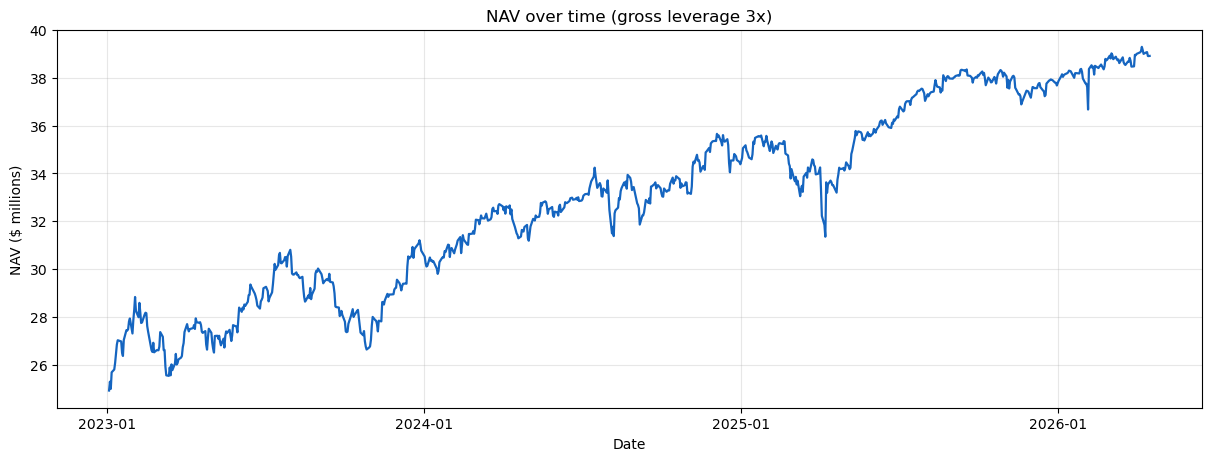

In [89]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "ALL_BT" not in dir() or not ALL_BT:
    raise RuntimeError("Run the backtest cell first (ALL_BT missing).")

ref = max(LEVERAGE_RUNS)
bt = ALL_BT[ref]
nav = bt["nav"].astype(float)

fig, ax = plt.subplots(figsize=(12, 4.5), layout="constrained")
ax.plot(nav.index, nav / 1e6, color="#1565C0", lw=1.6)
ax.set_title(f"NAV over time (gross leverage {ref}x)")
ax.set_ylabel("NAV ($ millions)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(alpha=0.3)
plt.show()


## Pair allocation — % of total gross over time

Each pair’s gross exposure (long + short legs) as a percentage of total portfolio gross on each day, from `ALL_PAIR_GROSS` (same idea as v15).

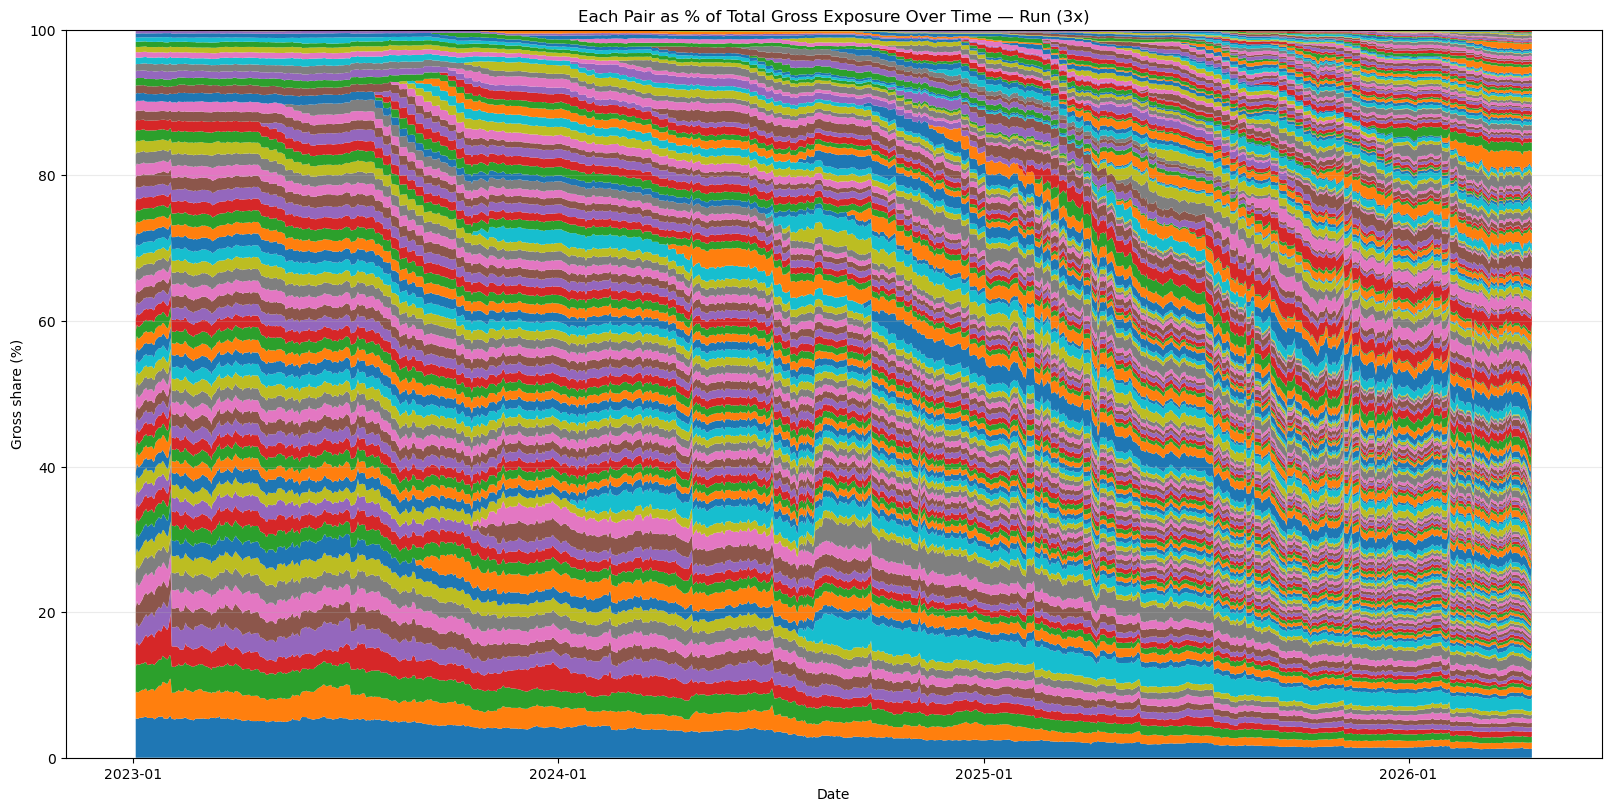

Pairs plotted: 196 | Date range: 2023-01-03 -> 2026-04-17
Top 15 pairs by average gross share (%):


,avg_gross_share_pct
SOXX/SOXL,3.196496
TSLA/TSLL,2.122659
FXI/YINN,2.088984
COIN/CONL,1.703606
NVDA/NVDL,1.650920
BABA/BABX,1.516368
EWY/KORU,1.508412
GDX/DUST,1.410073
QQQ/TQQQ,1.395123
ETHA/ETHU,1.364606


In [90]:
# ---- Pair gross share over time (% of total gross; each pair) ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

if "ALL_PAIR_GROSS" in globals() and isinstance(ALL_PAIR_GROSS, dict) and len(ALL_PAIR_GROSS) > 0:
    ref_lev = max(ALL_PAIR_GROSS)
    gross_df = ALL_PAIR_GROSS[ref_lev].copy()
    run_label = f"Run ({ref_lev}x)"
else:
    raise RuntimeError("No pair gross time series found. Run the backtest cell first.")

if gross_df is None or gross_df.empty:
    raise RuntimeError("Pair gross time series is empty.")

gross_df = gross_df.copy()
gross_df.index = pd.to_datetime(gross_df.index)
gross_df = gross_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

total_gross = gross_df.sum(axis=1).replace(0.0, np.nan)
pair_gross_pct = gross_df.div(total_gross, axis=0).fillna(0.0) * 100.0

pair_order = pair_gross_pct.mean(axis=0).sort_values(ascending=False).index.tolist()
pair_gross_pct = pair_gross_pct[pair_order]

fig, ax = plt.subplots(figsize=(16, 8), layout="constrained")
ax.stackplot(pair_gross_pct.index, pair_gross_pct.T.values, linewidth=0)
ax.set_title(f"Each Pair as % of Total Gross Exposure Over Time — {run_label}")
ax.set_ylabel("Gross share (%)")
ax.set_xlabel("Date")
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(axis="y", alpha=0.25)
plt.show()

print(f"Pairs plotted: {pair_gross_pct.shape[1]} | Date range: {pair_gross_pct.index.min().date()} -> {pair_gross_pct.index.max().date()}")
print("Top 15 pairs by average gross share (%):")
display(pair_gross_pct.mean().sort_values(ascending=False).head(15).to_frame("avg_gross_share_pct"))

## Concentration — gross exposure by underlying

Bar chart of the aggregate portfolio *gross* weight contributed by each underlying (sum of pair weights sharing the same underlying).

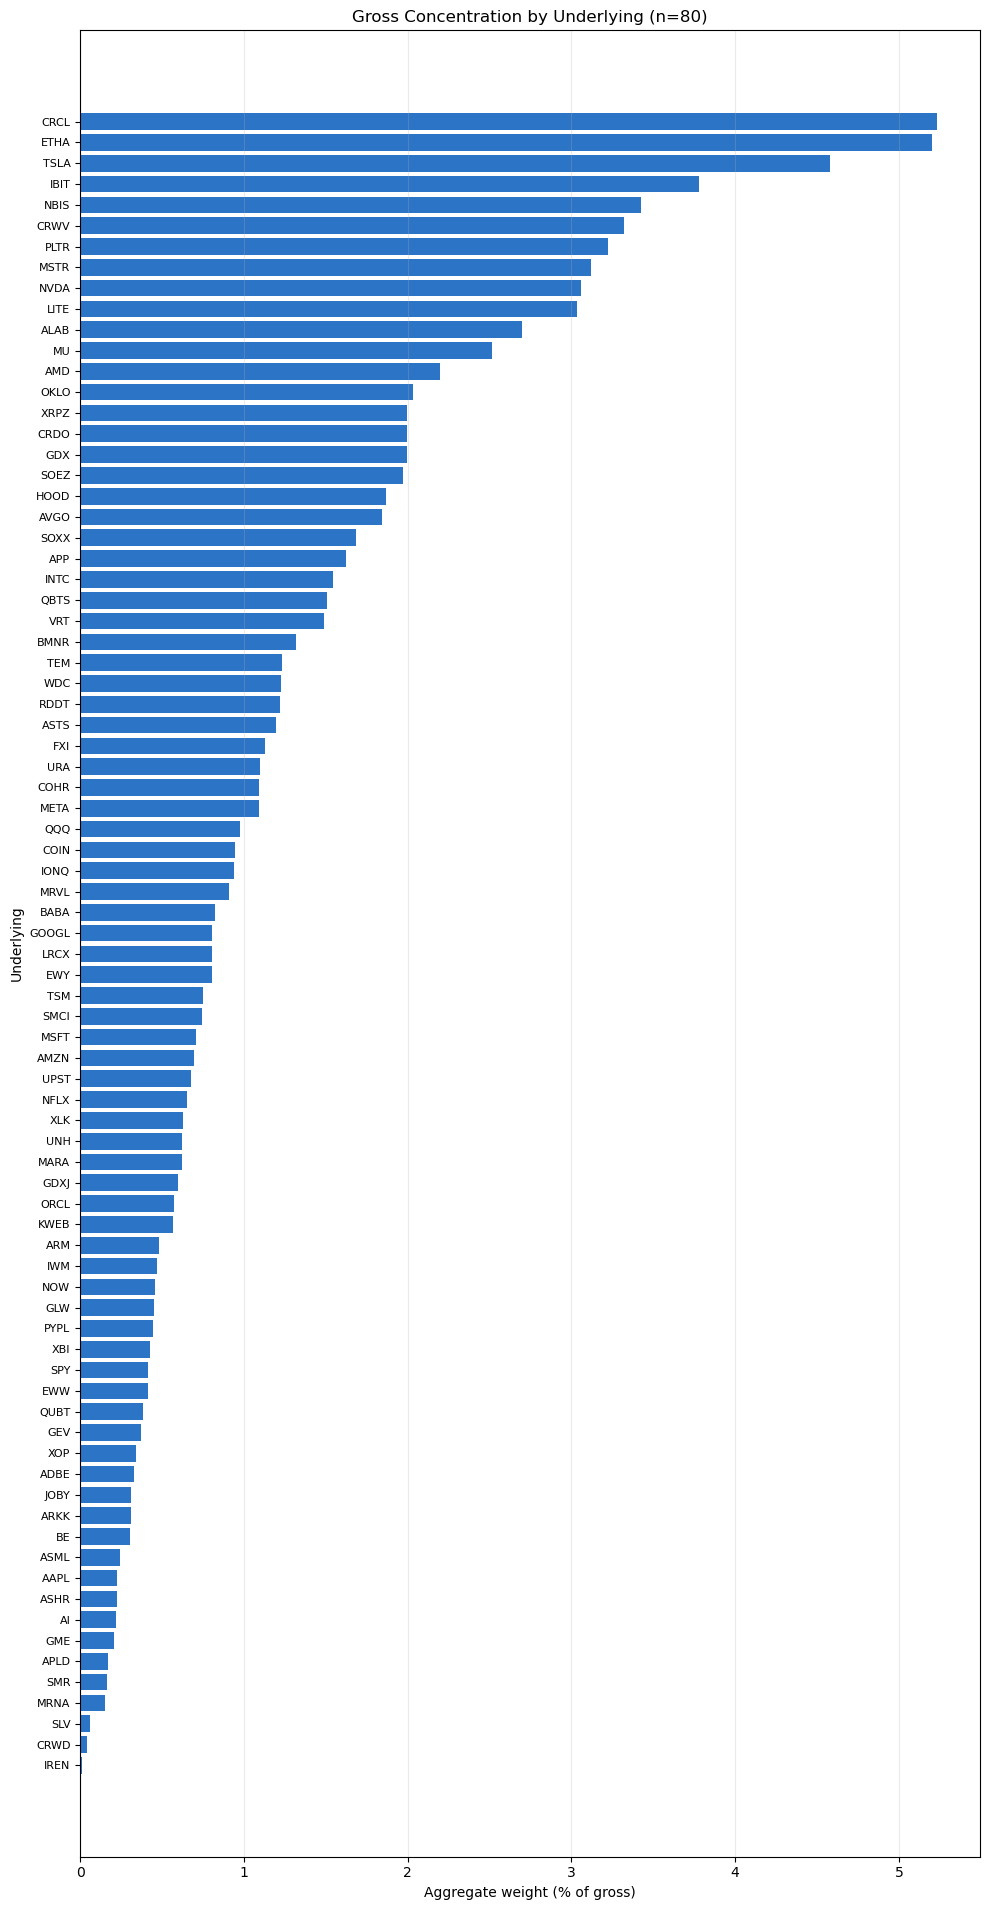

In [91]:
import matplotlib.pyplot as plt

if "w_df" not in globals() or w_df.empty:
    raise RuntimeError("Run the sizing cell first (w_df not found).")

und_w = (
    w_df.loc[w_df["weight"] > 0, ["und", "weight"]]
    .groupby("und", as_index=False)["weight"].sum()
    .sort_values("weight", ascending=True)
)
if und_w.empty:
    raise RuntimeError("No strictly positive weights found.")

n = len(und_w)
fig_h = min(24, max(6, 0.24 * n))
fig, ax = plt.subplots(figsize=(10, fig_h))
ax.barh(und_w["und"], und_w["weight"] * 100.0, color="#1565C0", alpha=0.9)
ax.set_title(f"Gross Concentration by Underlying (n={n})")
ax.set_xlabel("Aggregate weight (% of gross)")
ax.set_ylabel("Underlying")
ax.grid(True, axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()
